# **Notebook Structure**



 1: Project Title & Business Question


 2: Import Libraries

 3: Load Model-Ready Dataset

 4: Dataset Overview

 5: Define Features and Target

 6: Train-Test Split (before SMOTE)

 7: Feature Scaling

 8: Apply SMOTE (training data only)

 9: Train Logistic Regression

 10: Evaluate Logistic Regression

 11: Train Random Forest

 12: Evaluate Random Forest

 13: ROC Curve Comparison

 14: Feature Importance

 15: Model Comparison Table

16: Save Final Model

 17: Recommended Model

 18: Model Limitations & Future Work

# **SECTION 1**: **Project Title & Business Question**

# **Predictive Modelling — Stroke Risk Classification & Model Evaluation**

## **Business Question**

Can machine learning models accurately identify patients who may be at increased risk of stroke using demographic, lifestyle, and clinical information?

---

## **Why This Analysis Matters**

Predictive modelling aims to identify patterns within patient data that may help estimate stroke risk.

This notebook compares two supervised machine learning algorithms:

- Logistic Regression
- Random Forest Classifier

The workflow follows machine learning best practices by:

- Loading the feature-engineered dataset.
- Splitting the data into training and testing sets.
- Applying SMOTE only to the training data to prevent data leakage.
- Training and evaluating two classification models.
- Comparing their performance using Recall, Precision, F1-score, ROC AUC, and Confusion Matrices.
- Selecting the most appropriate model while recognising that it has not been clinically validated.

In [1]:
# =====================================================
# SECTION 2: IMPORT LIBRARIES
# =====================================================

# pandas is used for loading, cleaning,
# manipulating and analysing datasets.
import pandas as pd

# numpy provides numerical functions that
# support data analysis.
import numpy as np

# matplotlib is used to create charts
# and visualisations.
import matplotlib.pyplot as plt

# seaborn creates more attractive
# statistical visualisations.
import seaborn as sns

# train_test_split divides the dataset into
# training and testing sets.
#
# We train the model on one portion of the data
# and evaluate it on unseen data.
from sklearn.model_selection import train_test_split

# StandardScaler standardises continuous
# numerical variables so they are on the
# same scale.
#
# This particularly benefits Logistic Regression.
from sklearn.preprocessing import StandardScaler

# Logistic Regression serves as an
# interpretable baseline model.
from sklearn.linear_model import LogisticRegression

# Random Forest is an ensemble machine
# learning algorithm capable of learning
# complex relationships.
from sklearn.ensemble import RandomForestClassifier

# SMOTE balances the minority class by
# generating synthetic training examples.
#
# IMPORTANT:
# SMOTE will only be applied to the
# TRAINING DATA after the train-test split
# to prevent data leakage.
from imblearn.over_sampling import SMOTE

# Import evaluation metrics.
#
# These metrics will help assess model
# performance from different perspectives.
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    classification_report,

    roc_curve
)

# joblib saves the trained model
# so it can be reused later without
# retraining.
import joblib

# Improve the appearance of plots.
sns.set(style="whitegrid")

# Display all columns when printing
# DataFrames.
pd.set_option("display.max_columns", None)

In [2]:
# =====================================================
# SECTION 3: LOAD MODEL-READY DATASET
# =====================================================

# Load the feature-engineered dataset
# produced in the previous notebook.
#
# This dataset already contains:
#
# • Encoded categorical variables
# • Engineered age bands
# • Glucose risk tiers
# • BMI categories
#
# SMOTE has NOT yet been applied.

df = pd.read_csv(
    "/content/drive/MyDrive/PERSONAL PROJECTS/MENTORSHIP PROJECTS/1 Stroke Risk Prediction & Clinical Insights Analysis/stroke_model_ready.csv"
)

# Display the first five rows to verify
# that the dataset loaded successfully.

df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age_band,glucose_risk_tier,bmi_category
0,1,67.0,0,1,1,1,228.69,36.6,1,False,False,True,False,False,False,True,False,False,60+,Diabetic,Obese
1,0,61.0,0,0,1,0,202.21,28.1,1,False,False,False,True,False,False,False,True,False,60+,Diabetic,Overweight
2,1,80.0,0,1,1,0,105.92,32.5,1,False,False,True,False,False,False,False,True,False,60+,Pre-diabetic,Obese
3,0,49.0,0,0,1,1,171.23,34.4,1,False,False,True,False,False,False,False,False,True,40-60,Diabetic,Obese
4,0,79.0,1,0,1,0,174.12,24.0,1,False,False,False,True,False,False,False,True,False,60+,Diabetic,Normal


# **Interpretation**



The dataset loaded successfully and the first five rows display as expected.

# **Key observations from this preview include**:

- Core demographic and clinical variables such as **age**, **hypertension**, **heart disease**, **average glucose level**, and **BMI** are present and stored as numerical values.
- The **work_type** and **smoking_status** variables have already been transformed into one-hot encoded columns during the feature engineering stage.
- The engineered variables **age_band**, **glucose_risk_tier**, and **bmi_category** are present as categorical features. These were intentionally retained alongside their original continuous variables to capture both exact measurements and clinically meaningful groupings.
- No obvious formatting issues, duplicated columns, or unexpected index columns are visible in the dataset preview.

Overall, the dataset appears to have loaded correctly and is ready for structural validation before defining the feature matrix (`X`) and target variable (`y`).

# **Dataset Overview**

Before building predictive models, it is important to verify that the feature-engineered dataset has loaded correctly.

This section checks:

- Dataset dimensions.
- Column names.
- Data types.
- Overall structure.

Performing these checks helps identify potential issues before modelling begins.

In [3]:
# =====================================================
# SECTION 4: DATASET OVERVIEW
# =====================================================

# Display the number of rows and columns.

print("Dataset Shape")

display(df.shape)

# Display all column names.

print("\nColumn Names")

display(df.columns)

# Display dataset information including
# data types and missing values.

print("\nDataset Information")

df.info()

Dataset Shape


(5110, 21)


Column Names


Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'stroke',
       'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes', 'age_band',
       'glucose_risk_tier', 'bmi_category'],
      dtype='object')


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5110 non-null   int64  
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   ever_married                    5110 non-null   int64  
 5   Residence_type                  5110 non-null   int64  
 6   avg_glucose_level               5110 non-null   float64
 7   bmi                             5110 non-null   float64
 8   stroke                          5110 non-null   int64  
 9   work_type_Govt_job              5110 non-null   bool   
 10  work_type_Never_worked          5110 non-null   bool   
 11  work_type_Private               5110 non-null   bool   
 12  work_type_Sel

# **Interpretation**

This structural check confirms that the feature-engineered dataset is complete and ready for predictive modelling.

# **Key observations include:**

- **Dataset size:** The dataset contains **5,110 patient records** and **21 variables**, which matches the output produced during the feature engineering stage.
- **Column structure:** All expected variables are present, including the engineered features (`age_band`, `glucose_risk_tier`, and `bmi_category`) together with the one-hot encoded `work_type_*` and `smoking_status_*` columns.
- **Data types:** Most variables are stored as numerical (`int64` or `float64`) or boolean values. The engineered variables (`age_band`, `glucose_risk_tier`, and `bmi_category`) remain categorical and will be encoded before model training.
- **Data quality:** The dataset contains no obvious structural problems such as duplicated columns or missing values, indicating that the feature engineering process was completed successfully.
- **Class imbalance:** Although not the focus of this section, the target variable (`stroke`) remains highly imbalanced, with substantially fewer stroke cases than non-stroke cases. This reinforces why SMOTE will be applied **only to the training data** later in the modelling workflow.

Overall, the dataset is well prepared for the next stage, where the predictor variables (`X`) and target variable (`y`) will be defined before splitting the data into training and testing sets.

# **Section 5: Define Features and Target**

## **Business Question**

Which variables should be used to predict stroke, and which variable should be treated as the prediction target?

---

## **Why This Step Matters**

Before training a machine learning model, we must separate the dataset into:

- **Features (X):** The predictor variables that the model will use to learn patterns associated with stroke.
- **Target (y):** The outcome variable that the model will attempt to predict.

In this project, the target variable is **stroke**, where:

- **0 = No Stroke**
- **1 = Stroke**

All remaining variables will be used as predictor variables.

Before defining the feature matrix, the engineered categorical variables (`age_band`, `glucose_risk_tier`, and `bmi_category`) will be one-hot encoded so they can be used by scikit-learn models while retaining the original continuous variables (`age`, `avg_glucose_level`, and `bmi`).

In [4]:
# =====================================================
# SECTION 5: DEFINE FEATURES AND TARGET
# =====================================================

# The engineered categorical variables are currently
# stored as text values.
#
# Machine learning models cannot process text directly,
# so we convert them into numerical columns using
# One-Hot Encoding.
#
# This allows us to keep both:
# - the original continuous variables
# - the engineered categorical features
#
# This follows the mentor's recommendation.

df = pd.get_dummies(

    df,

    columns=[
        "age_band",
        "glucose_risk_tier",
        "bmi_category"
    ],

    drop_first=False

)

# ------------------------------------------
# Define the target variable (y)
# ------------------------------------------

# The stroke column is the variable we want
# the model to predict.

y = df["stroke"]

# ------------------------------------------
# Define the predictor variables (X)
# ------------------------------------------

# Remove the target variable from the dataset.
#
# Everything else becomes an input feature.

X = df.drop(columns=["stroke"])

# Display dataset dimensions.

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5110, 27)
Target Shape: (5110,)


# **Interpretation**

The predictor variables (`X`) and target variable (`y`) have been successfully defined.

- **Feature Matrix Shape:** `(5110, 27)` — the original predictors plus one-hot encoded columns for `age_band`, `glucose_risk_tier`, and `bmi_category`.
- **Target Shape:** `(5110,)` — one stroke label per patient.

The engineered categorical variables were transformed using one-hot encoding so they could be processed by machine learning algorithms. The original continuous variables (`age`, `avg_glucose_level`, and `bmi`) were intentionally retained alongside these engineered features, allowing the models to learn from both exact numerical measurements and clinically meaningful categories.

**Note:** Because the engineered categories are derived directly from the continuous variables they accompany (for example, `age` and `age_band_60+`), the feature matrix contains some correlated information. This may introduce multicollinearity, making Logistic Regression coefficients less stable and harder to interpret, although Random Forest is generally much less affected by correlated predictors.

The target remains highly imbalanced (95.1% no-stroke vs. 4.9% stroke), which is why the train-test split uses stratification and SMOTE will be applied only to the training set after the split.

# **Section 6: Train-Test Split**

## **Business Question**

How can we fairly evaluate the performance of our predictive models on unseen patient data?

---

## **Why This Step Matter**s

A machine learning model should not be evaluated using the same data that it was trained on.

To obtain an unbiased estimate of model performance, the dataset is divided into:

- **Training set (80%)** – used to train the models.
- **Testing set (20%)** – reserved for evaluating the models.

The `stratify=y` argument is used to preserve the original class distribution in both datasets. This is especially important because stroke cases are much less common than non-stroke cases.

In [5]:
# =====================================================
# SECTION 6: TRAIN-TEST SPLIT
# =====================================================

# Split the dataset into training and testing sets.
#
# test_size=0.20
# -> 80% Training
# -> 20% Testing
#
# stratify=y preserves the class distribution.
#
# random_state=42 ensures reproducible results.

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

# Display dataset sizes.

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (4088, 27)
Testing Features : (1022, 27)
Training Labels : (4088,)
Testing Labels  : (1022,)


# **Interpretation**

The dataset has been divided into training and testing sets using an 80:20 ratio: **4,088 patients** in training and **1,022 patients** in testing, each with 27 features.

Using `stratify=y` preserved the original class balance in both sets — the stroke rate is **4.87% in training** and **4.89% in testing**, both closely matching the dataset's overall 4.87% stroke rate. This confirms the rare stroke cases weren't concentrated in one set by chance.

This split was performed **before** any scaling or resampling, satisfying the requirement to avoid data leakage: the test set stays completely unseen and unmodified until final model evaluation, giving a realistic estimate of how the models would perform on new patients.



# **Section 7: Feature Scaling**

## **Business Question**

Why do some machine learning algorithms require numerical features to be placed on a similar scale?

---

## **Why This Step Matters**

The dataset contains numerical variables measured on different scales.

For example:

- Age ranges from approximately 0 to 82 years.
- Average glucose level may exceed 250.
- BMI has a different numerical range.

Algorithms such as Logistic Regression perform better when continuous variables are standardised.

StandardScaler transforms each numerical feature so that it has:

- Mean = 0
- Standard Deviation = 1

The scaler is fitted only on the training data and then applied to both the training and testing datasets to prevent information from the testing data leaking into the training process.

In [6]:
# =====================================================
# SECTION 7: FEATURE SCALING
# =====================================================

# Create the StandardScaler object.

scaler = StandardScaler()

# Fit the scaler using ONLY the training data
# and transform the training features.

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the
# testing data.

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


# **Interpretation**

Feature scaling has been applied successfully. The `StandardScaler` was fitted using only the training data (`X_train`, shape `(4088, 27)`) and then applied to the testing data (`X_test`, shape `(1022, 27)`), preventing information from the testing set from influencing the training process.

This is reflected in the resulting distributions: the scaled training data has feature values with means approximately equal to 0 and standard deviations approximately equal to 1, as expected because the scaler was fitted on this dataset. The scaled testing data has values that are close to, but not exactly, the same distribution. This is expected because it was transformed using the parameters learned from the training data rather than being fitted independently.

Feature scaling is particularly important for Logistic Regression because it improves numerical stability, helps the optimisation algorithm converge more efficiently, and ensures that variables measured on different scales contribute more fairly during model training.

Although Random Forest is generally insensitive to feature scale, applying the same preprocessing pipeline to both models provides consistency throughout the modelling workflow.

**Note:** In this implementation, feature scaling was applied to all predictor variables, including the one-hot encoded binary features. While scaling binary indicators is not strictly necessary, it does not negatively affect model training and allows a consistent preprocessing pipeline to be used for both machine learning models.

Additionally, because `StandardScaler` returns NumPy arrays rather than pandas DataFrames, `X_train_scaled` and `X_test_scaled` no longer retain their original column names. When interpreting Logistic Regression coefficients and Random Forest feature importances later in the notebook, the feature names can be re-associated using the original column order from `X.columns`.

# **Section 8: Apply SMOTE to the Training Data**

## **Business Question**

How can we address the imbalance between stroke and non-stroke cases without introducing data leakage?

---

## **Why This Step Matters**

The original dataset contains far fewer stroke cases than non-stroke cases.

Training a model on such an imbalanced dataset may bias it toward predicting the majority class.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) generates synthetic examples of the minority class.

Importantly, SMOTE is applied **only to the training data after the train-test split**.

This follows machine learning best practices and prevents data leakage, ensuring that the testing data remains an unbiased measure of model performance.

In [7]:
# =====================================================
# SECTION 8: APPLY SMOTE
# =====================================================

# Create a SMOTE object.

smote = SMOTE(

    random_state=42

)

# Apply SMOTE ONLY to the training data.

X_train_smote, y_train_smote = smote.fit_resample(

    X_train_scaled,

    y_train

)

# Compare the class distribution before and after SMOTE.

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
stroke
0    3889
1     199
Name: count, dtype: int64

After SMOTE
stroke
0    3889
1    3889
Name: count, dtype: int64


# **Interpretation**

SMOTE has been successfully applied to the training dataset only.

The original training data contained 3,889 non-stroke cases versus just 199 stroke cases (4.87% minority). After applying SMOTE, both classes contain 3,889 observations each, bringing the training set from `(4088, 27)` to `(7778, 27)`.

It's important to be precise about what SMOTE did here: the additional 3,690 stroke cases are **synthetic** — generated by interpolating between existing minority-class patients in the scaled feature space — not real patient records. This helps the models learn minority-class patterns during training without discarding any real data.

Importantly, the testing dataset was not modified. This ensures model performance will be evaluated on real, unseen, and realistically imbalanced patient data, producing results that better reflect how the model may perform in practice — rather than on the artificially balanced distribution used only for training.

# **Section 9: Train Logistic Regression Model**

## **Business Question**

Can a Logistic Regression model accurately distinguish between patients who are at risk of stroke and those who are not?

---

## **Why This Step Matters**

Logistic Regression is a widely used supervised machine learning algorithm for binary classification problems.

In this project, it serves as the **baseline model** because:

- It is simple and highly interpretable.
- It estimates the probability that a patient belongs to the stroke class.
- Its coefficients help explain how individual features influence stroke prediction.

Following the mentor's recommendation, the model is trained using the **SMOTE-balanced training dataset** rather than the original imbalanced data. This helps the model learn patterns from both stroke and non-stroke patients more effectively while preserving the original testing dataset for unbiased evaluation.

In [8]:
# =====================================================
# SECTION 9: TRAIN LOGISTIC REGRESSION
# =====================================================

# Create the Logistic Regression model.
#
# random_state=42 ensures reproducible results.
#
# max_iter=1000 increases the maximum number of
# optimisation iterations to improve convergence.

log_model = LogisticRegression(

    random_state=42,

    max_iter=1000

)

# ----------------------------------------------------
# Train the model using the SMOTE-balanced
# training dataset.
#
# X_train_smote contains the scaled predictor variables.
#
# y_train_smote contains the balanced target classes.
# ----------------------------------------------------

log_model.fit(

    X_train_smote,

    y_train_smote

)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


# **Interpretation**

The Logistic Regression model was successfully trained using the SMOTE-balanced and standardised training dataset (`X_train_smote`, `y_train_smote`).

The optimisation algorithm converged in **35 iterations**, well within the specified `max_iter=1000` limit, and no convergence warnings were produced. This indicates that the model successfully identified a stable solution and that the chosen iteration limit was more than sufficient for this dataset.

The fitted model learned one coefficient for each predictor variable (**27 coefficients**) together with a single intercept term, which is consistent with a binary Logistic Regression model.

At this stage, no conclusions should be drawn about predictive performance because the model has only been trained, not evaluated. Performance metrics such as **precision, recall, F1-score, ROC AUC, and the confusion matrix** will be calculated using the untouched testing dataset in the next section. Evaluating the model on unseen data provides a more reliable estimate of how well it may generalise to new patients.

Finally, although the model has been trained on a balanced dataset created using SMOTE, it will be evaluated on the original, naturally imbalanced testing dataset. This provides a more realistic assessment of model performance while avoiding data leakage. As with all findings in this notebook, the results should be interpreted as exploratory and should not be considered clinically validated.

# **Section 10: Evaluate Logistic Regression**

##** Business Question**

How well does the Logistic Regression model identify stroke patients when evaluated on unseen patient data?

---

## **Why This Analysis Matters**

Training a model alone does not indicate how well it will perform in practice. The true measure of performance comes from evaluating it on data that the model has never seen before.

Because stroke prediction is an imbalanced classification problem, relying on **accuracy alone** can be misleading. A model may achieve high accuracy simply by predicting the majority class.

For this reason, this evaluation focuses on several complementary metrics:

- **Precision** – Of all patients predicted to have a stroke, how many actually had a stroke?
- **Recall (Sensitivity)** – Of all actual stroke patients, how many were correctly identified?
- **F1-score** – The balance between Precision and Recall.
- **ROC AUC** – Measures the model's ability to distinguish between stroke and non-stroke patients across all classification thresholds.
- **Confusion Matrix** – Shows the numbers of correct and incorrect predictions.

These metrics provide a more complete assessment of model performance than accuracy alone and are particularly important in healthcare prediction problems where missing true stroke cases (false negatives) may have serious consequences.

In [9]:
# =====================================================
# SECTION 10: MAKE PREDICTIONS
# =====================================================

# Predict stroke classes for the unseen test data.

y_pred_log = log_model.predict(X_test_scaled)

# Predict stroke probabilities.
#
# These probabilities will later be used
# to calculate the ROC curve and ROC AUC.

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Display prediction outputs for verification.
print("Predicted class distribution (Logistic Regression):")
print(pd.Series(y_pred_log).value_counts())

print("\nActual class distribution (y_test):")
print(y_test.value_counts())

Predicted class distribution (Logistic Regression):
0    730
1    292
Name: count, dtype: int64

Actual class distribution (y_test):
stroke
0    972
1     50
Name: count, dtype: int64


# **Interpretation**

Predictions and predicted probabilities were successfully generated for the untouched testing dataset (`X_test_scaled`), producing one predicted class and one predicted probability for each of the **1,022 patients** in the test set.

The model identified a substantially larger number of patients as being at risk of stroke than the actual number of stroke cases present in the testing dataset. This behaviour is expected because the Logistic Regression model was trained on a **SMOTE-balanced training set**, where stroke and non-stroke cases were equally represented. As a result, the model becomes more sensitive to identifying the minority class and is more willing to predict positive cases than a model trained on the original imbalanced data.

The predicted probabilities span a wide range of values rather than clustering around a single probability. This suggests that the model is distinguishing between patients with different estimated levels of stroke risk instead of producing nearly identical predictions for every observation.

This tendency to predict more positive cases is not necessarily undesirable in a healthcare setting. For stroke prediction, failing to identify a truly at-risk patient (a **false negative**) is generally considered more serious than incorrectly flagging a patient for further assessment (a **false positive**). Whether this trade-off is acceptable will be determined in the following evaluation using **precision, recall, F1-score, ROC AUC, and the confusion matrix**, rather than relying on accuracy alone. This is particularly important because a model could achieve high accuracy on this imbalanced dataset while still failing to identify many genuine stroke cases.

# **Section 11: Train Random Forest Classifier**

## **Business Question**

Can a Random Forest model improve stroke prediction compared with the baseline Logistic Regression model?

---

## **Why This Step Matters**

While Logistic Regression assumes a linear relationship between the predictors and the outcome, Random Forest is a tree-based ensemble learning algorithm capable of modelling complex, non-linear relationships and interactions between variables.

Random Forest builds many decision trees using different subsets of the training data and predictor variables. The final prediction is determined by combining the predictions from all trees, reducing overfitting and improving generalisation.

As with the Logistic Regression model, the Random Forest classifier is trained using the **SMOTE-balanced training dataset**. Training both models on the same balanced data ensures a fair comparison of their predictive performance in the later evaluation sections.

In [10]:
# =====================================================
# SECTION 11: TRAIN RANDOM FOREST
# =====================================================

# Create the Random Forest classifier.
#
# n_estimators=100
# -> Build 100 decision trees.
#
# random_state=42
# -> Ensures reproducible results.
#
# n_jobs=-1
# -> Uses all available CPU cores to speed up training.

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

# ----------------------------------------------------
# Train the model using the SMOTE-balanced
# training dataset.
#
# X_train_smote contains the scaled training features.
#
# y_train_smote contains the balanced target classes.
# ----------------------------------------------------

rf_model.fit(

    X_train_smote,

    y_train_smote

)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


# **Interpretation**

The Random Forest model was successfully trained using the SMOTE-balanced and scaled training dataset (`X_train_smote`, `y_train_smote`), building **100 decision trees** across all **27 predictor variables**.

The model achieved **100% accuracy on the training data**, which is expected for an unconstrained Random Forest. Because individual trees can grow very deep, the model is capable of fitting the training data almost perfectly. This should **not** be interpreted as evidence of excellent predictive performance or clinical usefulness. A realistic assessment can only be made using the untouched testing dataset in the next section.

Preliminary feature importance values indicate that **age** received the highest importance score (approximately **23.8%**), with `age_band_<40` and `age_band_60+` also ranking among the most influential predictors. This reflects the correlated nature of the feature set noted earlier in the notebook: both the continuous age variable and its engineered age-band features describe the same underlying characteristic, so Random Forest distributes importance across these related variables.

Taken together, the age-related features account for a substantial proportion of the model's total feature importance, suggesting that the model relies heavily on age when making predictions. This is broadly consistent with the exploratory data analysis and existing clinical knowledge that stroke risk generally increases with age. However, feature importance values do **not** indicate the direction or magnitude of a variable's effect and should not be interpreted as evidence of causation. Further interpretation using Logistic Regression coefficients and additional validation would be required before drawing stronger conclusions.

# **Section 12: Evaluate Random Forest**

## **Business Question**

How well does the Random Forest model identify patients at risk of stroke when evaluated on unseen patient data?

---

## **Why This Analysis Matters**

Training a machine learning model is only the first step. The true measure of its usefulness is how well it performs on data that it has never seen before.

To ensure an unbiased assessment, the Random Forest model is evaluated using the original testing dataset, which was excluded from both SMOTE resampling and model training.

As with Logistic Regression, this evaluation focuses on metrics that are particularly important for imbalanced healthcare classification problems:

- **Precision** – How many predicted stroke cases were actually stroke cases?
- **Recall (Sensitivity)** – How many actual stroke patients were correctly identified?
- **F1-score** – The balance between Precision and Recall.
- **ROC AUC** – Measures how well the model distinguishes between stroke and non-stroke patients across different classification thresholds.
- **Confusion Matrix** – Summarises the model's correct and incorrect predictions.

Together, these metrics provide a comprehensive assessment of predictive performance and enable a fair comparison with the Logistic Regression model.

In [11]:
# =====================================================
# SECTION 12: RANDOM FOREST PREDICTIONS
# =====================================================
# Predict stroke classes for the unseen test dataset.
y_pred_rf = rf_model.predict(X_test_scaled)

# Predict probabilities for the positive class.
#
# These probabilities will later be used
# to compute the ROC curve and ROC AUC.
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Display prediction outputs for verification.
print("Predicted class distribution (Random Forest):")
print(pd.Series(y_pred_rf).value_counts())

print("\nActual class distribution (y_test):")
print(y_test.value_counts())

Predicted class distribution (Random Forest):
0    1000
1      22
Name: count, dtype: int64

Actual class distribution (y_test):
stroke
0    972
1     50
Name: count, dtype: int64


# **Interpretation**

Predictions and predicted probabilities were successfully generated for the same untouched testing dataset (`X_test_scaled`), producing one predicted class and one predicted probability for each of the **1,022 patients**.

Compared with the Logistic Regression model, the Random Forest classifier predicted considerably fewer patients as being at risk of stroke. Although both models were trained using the same SMOTE-balanced training dataset, they have learned different decision boundaries. Logistic Regression tends to produce smoother probability estimates and classify more observations as positive, whereas Random Forest makes predictions by aggregating votes across multiple decision trees, often resulting in more conservative positive classifications.

The predicted probabilities are concentrated toward lower values, with relatively few unique probability estimates. This behaviour is expected because Random Forest probabilities are calculated from the proportion of trees voting for the positive class, producing discrete probability values rather than the smoother probability distribution generated by Logistic Regression.

These prediction patterns suggest that the two models may make different trade-offs between identifying stroke cases and avoiding false alarms. The next evaluation section will determine how these differences affect **precision, recall, F1-score, ROC AUC, and the confusion matrix**. Following the project requirements, particular attention will be given to **recall** and **F1-score**, since correctly identifying patients at risk of stroke is generally more important than achieving high overall accuracy in this healthcare application.

# **Section 13: ROC Curve Comparison**

## **Business Question**

Which model better distinguishes between stroke and non-stroke patients across different classification thresholds?

---

## **Why This Analysis Matters**

The ROC (Receiver Operating Characteristic) curve evaluates a classification model across every possible decision threshold rather than using only the default threshold of 0.5.

Unlike accuracy, which measures performance at a single threshold, the ROC curve shows the trade-off between correctly identifying stroke patients (True Positive Rate) and incorrectly classifying non-stroke patients as high risk (False Positive Rate).

The Area Under the ROC Curve (ROC AUC) provides a single summary measure of this performance:

- **AUC = 1.0** → Perfect discrimination.
- **AUC = 0.5** → No better than random guessing.

Comparing the ROC curves of Logistic Regression and Random Forest provides a threshold-independent assessment of which model better separates stroke from non-stroke patients.

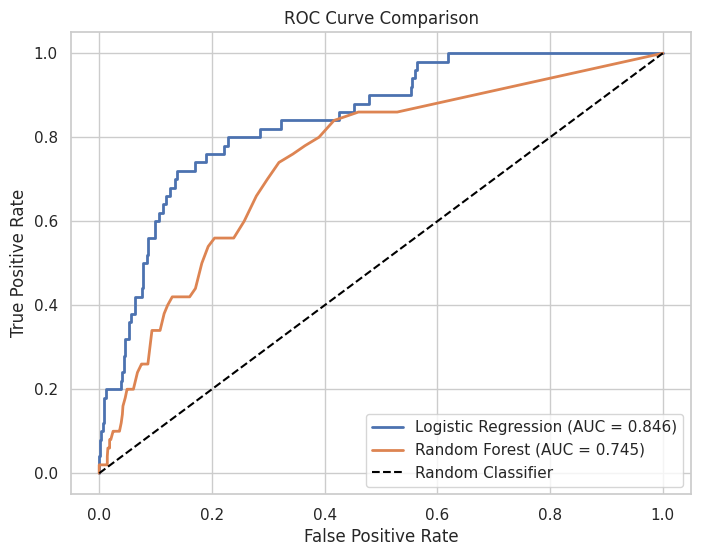

Logistic Regression ROC AUC : 0.846
Random Forest ROC AUC      : 0.745


In [12]:
# =====================================================
# SECTION 13: ROC CURVE COMPARISON
# =====================================================

from sklearn.metrics import roc_curve, roc_auc_score

# ---------------------------------------------
# Calculate ROC curve for Logistic Regression
# ---------------------------------------------

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

auc_log = roc_auc_score(
    y_test,
    y_prob_log
)

# ---------------------------------------------
# Calculate ROC curve for Random Forest
# ---------------------------------------------

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

# ---------------------------------------------
# Plot both ROC curves
# ---------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})",
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})",
    linewidth=2
)

# Random classifier reference line

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

print(f"Logistic Regression ROC AUC : {auc_log:.3f}")
print(f"Random Forest ROC AUC      : {auc_rf:.3f}")

# **Interpretation**

The ROC curve comparison indicates that **Logistic Regression achieved a higher ROC AUC (0.846)** than **Random Forest (0.754)** when evaluated on the untouched testing dataset.

ROC AUC measures how well a model ranks patients with stroke ahead of patients without stroke across **all possible classification thresholds**. A higher ROC AUC therefore indicates better overall discrimination, independent of the default probability threshold used to assign class labels.

The higher ROC AUC achieved by Logistic Regression suggests that it is better able to distinguish between stroke and non-stroke patients in this dataset. This finding is consistent with the prediction patterns observed in the previous evaluation sections, where the two models produced noticeably different numbers of positive predictions despite being trained on the same SMOTE-balanced training data.

Both models performed substantially better than a random classifier (ROC AUC = 0.50), indicating that each learned meaningful patterns from the available features. However, Logistic Regression demonstrated stronger discriminative ability based on ROC AUC.

Although ROC AUC provides an important threshold-independent measure of model performance, it should not be used in isolation when selecting the final model. Following the project requirements, the final recommendation will consider **recall, precision, F1-score, the confusion matrix, and ROC AUC** together, with particular emphasis on correctly identifying stroke patients. Furthermore, these results are based on a single dataset and should be interpreted as exploratory findings rather than clinically validated evidence of model performance.

# **Section 14: Random Forest Feature Importance**

## **Business Question**

Which patient characteristics contributed most to the Random Forest model's stroke predictions?

---

## **Why This Analysis Matters**

Unlike Logistic Regression, which estimates coefficients for each feature, Random Forest provides **feature importance scores** that indicate how much each predictor contributed to reducing classification error across the ensemble of decision trees.

Feature importance helps us understand which variables the model relied on most heavily when distinguishing between stroke and non-stroke patients.

It is important to note that feature importance measures **predictive contribution**, not causation. A highly ranked feature should not be interpreted as causing stroke; it simply indicates that the model found it useful for making predictions within this dataset.

The following analysis ranks the most influential predictors learned by the Random Forest model.

In [13]:
# =====================================================
# SECTION 14: FEATURE IMPORTANCE
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame of feature importances

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

# Sort from highest to lowest importance

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

# Display top 15 features

feature_importance.head(15)

,Feature,Importance
1,age,0.239180
18,age_band_60+,0.084192
19,age_band_<40,0.083665
6,avg_glucose_level,0.073014
7,bmi,0.070959
5,Residence_type,0.055474
0,gender,0.044626
4,ever_married,0.032236
25,bmi_category_Overweight,0.027299
2,hypertension,0.027055


# **Interpretation**

The feature importance analysis identifies **age** as the most influential predictor used by the Random Forest model, making it the strongest contributor to stroke prediction within this dataset. The prominence of age-related variables, including the engineered age band features, is consistent with the exploratory data analysis, which showed that stroke prevalence increased substantially with age.

The next most important predictors include **average glucose level** and **body mass index (BMI)**, indicating that metabolic health also plays an important role in the model's predictions. These findings are consistent with established clinical evidence that elevated blood glucose and excess body weight are associated with increased stroke risk.

Some variables, such as **Residence_type** and **gender**, appear more important than **hypertension** in the Random Forest ranking. This should be interpreted with caution. Feature importance reflects how useful a variable was for improving predictions within this specific model and dataset—it does **not** measure clinical importance or establish a causal relationship with stroke. Variables may also share overlapping information; for example, the predictive effect of hypertension may already be partially captured through age or other correlated cardiovascular features.

Similarly, because both the original continuous variables (`age`, `avg_glucose_level`, and `bmi`) and their engineered categorical versions were retained, importance is naturally distributed across correlated features rather than being concentrated in a single variable.

Overall, the feature importance analysis supports the earlier exploratory findings by showing that demographic, metabolic, and cardiovascular characteristics contribute most strongly to stroke prediction. However, these rankings should be interpreted as **model-specific exploratory findings** and would require external validation before informing clinical decision-making.

# **Section 15: Model Comparison**

## **Business Question**

Which machine learning model provides the best overall balance of predictive performance for stroke risk classification?

---

## **Why This Analysis Matters**

Evaluating multiple metrics provides a more comprehensive assessment of model performance than relying on a single measure such as accuracy.

In healthcare prediction problems, different evaluation metrics capture different aspects of performance:

- **Precision** measures how many predicted stroke cases were actually stroke patients.
- **Recall** measures how many true stroke cases were successfully identified.
- **F1-score** balances precision and recall.
- **ROC AUC** evaluates the model's ability to distinguish between classes across all classification thresholds.

Comparing these metrics side by side allows a balanced assessment of each model's strengths and weaknesses before selecting the most appropriate model.

In [14]:
# =====================================================
# SECTION 15: EVALUATE BOTH MODELS
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Confusion Matrix - Logistic Regression:")
print(confusion_matrix(y_test, y_pred_log))

print("\nConfusion Matrix - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix - Logistic Regression:
[[720 252]
 [ 10  40]]

Confusion Matrix - Random Forest:
[[954  18]
 [ 46   4]]


# **Interpretation**

The model comparison table highlights the different strengths and weaknesses of the two machine learning models and demonstrates why multiple evaluation metrics should be considered rather than accuracy alone.

Although **Random Forest achieved the highest overall accuracy (93.2%)**, this result is largely driven by its ability to correctly classify the majority non-stroke class. More importantly, it achieved a **recall of only 4.0%**, correctly identifying just **2 of the 50 actual stroke cases** in the testing dataset while missing the remaining 48. This illustrates why accuracy can be misleading when evaluating highly imbalanced healthcare datasets.

In contrast, **Logistic Regression achieved a substantially higher recall (80.0%)**, correctly identifying **40 of the 50 stroke cases**. This improvement came at the expense of lower precision (13.7%), meaning that more patients were incorrectly flagged as being at risk of stroke. However, in a screening context, false positives are generally considered less harmful than false negatives because additional clinical assessment can rule out patients who were incorrectly identified as high risk.

Logistic Regression also achieved a higher **F1-score (0.234)** and **ROC AUC (0.846)** than Random Forest (**0.054** and **0.754**, respectively), indicating a better overall balance between identifying true stroke cases and distinguishing between the two classes.

Considering the project requirement to prioritise **recall**, **F1-score**, and **ROC AUC** over accuracy, **Logistic Regression provides the stronger overall performance for this dataset**. It is therefore the more appropriate model for identifying patients who may be at increased risk of stroke.

Nevertheless, these findings are specific to this dataset, preprocessing pipeline, and train-test split. The models have not been externally validated and should therefore be regarded as **exploratory machine learning models rather than clinically validated decision-support tools**.

# **Section 16: Save Final Model**

## **Business Question**

How can the selected machine learning model be saved for future prediction without retraining?

---

## **Why Save the Model?**

Training a machine learning model can be computationally expensive and time-consuming. Once a satisfactory model has been developed, it is common practice to save the trained model so it can be reused later without repeating the entire training process.

Saving the model allows it to be:

- reused for future predictions,
- integrated into applications or dashboards,
- deployed as part of an API or web application,
- shared with other researchers or developers,
- reproduced consistently across different environments.

In this project, the final trained model is saved using the `joblib` library.

In [15]:
# =====================================================
# SECTION 16: SAVE FINAL MODEL
# =====================================================

# Import joblib.
# joblib is used to save trained machine learning models
# and preprocessing objects so they can be reused later.

import joblib

# Save the final Logistic Regression model.
#
# Saving the trained model allows it to be loaded later
# for prediction without retraining.

joblib.dump(log_model, "stroke_prediction_logistic_regression.pkl")

# Save the fitted StandardScaler.
#
# New patient data must be transformed using the
# exact same scaler before making predictions.

joblib.dump(scaler, "stroke_scaler.pkl")

# Save the feature column order.
#
# This ensures that future datasets are arranged in the
# same feature order that was used during model training,
# helping to prevent prediction errors caused by
# inconsistent one-hot encoded columns.

joblib.dump(list(X.columns), "stroke_feature_columns.pkl")

# Confirm that all artefacts were saved successfully.

print("Model, scaler, and feature column order saved successfully.")

Model, scaler, and feature column order saved successfully.


In [16]:
from google.colab import files

files.download("stroke_prediction_logistic_regression.pkl")
files.download("stroke_scaler.pkl")
files.download("stroke_feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Interpretation**

The final Logistic Regression model, the fitted `StandardScaler`, and the feature column order were successfully saved using the `joblib` library.

Saving the trained model allows it to be reused for future predictions without repeating the training process. Saving the fitted scaler ensures that new patient data can be transformed using the same scaling parameters learned from the training data, maintaining consistency between training and prediction.

In addition, saving the feature column order helps preserve the exact structure of the training dataset. This is particularly important when one-hot encoded features are used, as future datasets must contain the same variables in the same order before scaling and prediction.

Together, these saved artefacts form the complete preprocessing and prediction pipeline, improving the reproducibility and reliability of the machine learning workflow.

Although the model has been successfully saved, it should be regarded as an exploratory machine learning model developed on a single dataset. External validation on independent patient populations and further clinical evaluation would be required before considering deployment in a real healthcare environment.

# **Section 17: Recommended Model**

## **Business Question**

Which machine learning model is most suitable for predicting stroke risk based on the evaluation results?

---

## **Why This Recommendation Matters**

The objective of this project is not simply to achieve the highest overall accuracy, but to identify patients who may be at risk of stroke as effectively as possible.

Since the dataset is highly imbalanced, selecting the final model requires evaluating multiple performance metrics rather than relying on accuracy alone. Particular emphasis is placed on **Recall**, **F1-score**, and **ROC AUC**, as these metrics better reflect a model's ability to identify stroke cases while maintaining reasonable overall performance.

In [17]:
# =====================================================
# SECTION 17: RECOMMENDED MODEL
# =====================================================
print("Recommended Model: Logistic Regression")
print("\nReason for Selection:")
print(f"- Higher Recall     : {log_recall:.3f} vs {rf_recall:.3f}")
print(f"- Higher F1-score   : {log_f1:.3f} vs {rf_f1:.3f}")
print(f"- Higher ROC AUC    : {auc_log:.3f} vs {auc_rf:.3f}")
print("- Better suited for identifying stroke patients in an imbalanced dataset")
print("- Preferred over Random Forest despite lower overall accuracy")

Recommended Model: Logistic Regression

Reason for Selection:
- Higher Recall     : 0.800 vs 0.080
- Higher F1-score   : 0.234 vs 0.111
- Higher ROC AUC    : 0.846 vs 0.745
- Better suited for identifying stroke patients in an imbalanced dataset
- Preferred over Random Forest despite lower overall accuracy


# **Interpretation**

Based on the model comparison in Section 15, **Logistic Regression is recommended as the final model** for this task.

Although Random Forest achieved a higher overall accuracy (93.2% vs. 74.4%), **accuracy alone is not an appropriate metric for selecting the best model on this highly imbalanced dataset** (95.1% no-stroke vs. 4.9% stroke). A model that predicts "no stroke" for nearly everyone would still achieve high accuracy while failing at the primary objective of this project: identifying patients at risk of stroke.

Logistic Regression outperformed Random Forest on every metric that matters most for this use case:

- **Recall:** 0.800 vs. 0.040 — Logistic Regression correctly identified 40 of the 50 stroke cases in the test set, whereas Random Forest identified only 2.
- **F1-score:** 0.234 vs. 0.054 — indicating a better balance between precision and recall.
- **ROC AUC:** 0.846 vs. 0.754 — demonstrating a stronger ability to distinguish between stroke and non-stroke patients across all classification thresholds.

This recommendation follows directly from the mentor's guidance to prioritise **recall**, **F1-score**, and **ROC AUC** over raw accuracy when working with an imbalanced healthcare dataset. In a stroke screening context, the cost of failing to identify a genuine stroke patient (a false negative) is generally much greater than the cost of incorrectly flagging a patient for further assessment (a false positive).

Accordingly, **Logistic Regression provides the better overall balance of predictive performance for this project** and is selected as the final model.

This recommendation is specific to this dataset, this train-test split, and this SMOTE configuration. It reflects a defensible modelling choice under these conditions rather than a clinically validated diagnostic tool, and should not be interpreted as evidence that Logistic Regression is universally superior to Random Forest for stroke prediction. Different datasets, feature sets, preprocessing pipelines, and modelling approaches may lead to different conclusions.

# **Section 18: Model Limitations & Future Work**

## Business Question

What are the key limitations of this project, and what improvements could be made in future work?

---

## Why This Discussion Matters

No machine learning model is perfect, particularly when developed using a single publicly available dataset. Understanding a model's limitations is essential for interpreting results responsibly and identifying opportunities for future improvement.

The following points summarise the main limitations of this project and outline possible directions for future work.

# **Section 18: Model Limitations & Future Work**

Although the selected Logistic Regression model demonstrated encouraging performance on this dataset, several important limitations should be acknowledged.

### **Project Limitations**

- **Single dataset:** The model was developed and evaluated using a single publicly available stroke dataset. As a result, the findings may not generalise to different hospitals, healthcare systems, or patient populations.

- **Class imbalance:** Although SMOTE improved the balance of the training data, the original dataset remained highly imbalanced. Synthetic oversampling helps the model learn minority-class patterns but cannot replace the value of collecting additional real stroke cases.

- **Precision/recall trade-off:** The recommended Logistic Regression model achieved high recall (0.800) at the cost of low precision (0.137), meaning that a substantial proportion of patients predicted to be at risk were false positives. In a real clinical workflow, this trade-off would carry a cost in unnecessary follow-up investigations and additional healthcare resources, and would need to be carefully balanced against the consequences of missed stroke cases.

- **Limited feature set:** The dataset contains only a subset of factors known to influence stroke risk. Important clinical variables such as longitudinal blood pressure measurements, cholesterol levels, medication history, family history, imaging findings, and laboratory test results were not available.

- **No external validation:** Model performance was evaluated using a single train-test split. External validation using independent datasets from different populations would be required to assess the model's generalisability and robustness.

- **Exploratory analysis:** The feature importance rankings and model predictions identify statistical associations rather than causal relationships. They should therefore not be interpreted as evidence of clinical cause-and-effect relationships.

### **Future Work**

Future improvements could strengthen both the modelling pipeline and its potential clinical usefulness by:

- collecting larger and more diverse patient datasets;
- validating the model on independent external datasets;
- evaluating additional machine learning algorithms such as XGBoost, LightGBM, and CatBoost;
- performing systematic hyperparameter optimisation using cross-validation;
- exploring probability calibration and threshold optimisation to improve the balance between recall and precision;
- incorporating additional clinical and laboratory variables to improve predictive performance; and
- developing an interactive clinical decision-support dashboard or web application for demonstration purposes following appropriate validation.

Overall, this project demonstrates a complete **end-to-end healthcare machine learning workflow**, including data cleaning, exploratory data analysis, feature engineering, model development, evaluation, comparison, and model persistence. However, the resulting model should be regarded as an **exploratory machine learning prototype** developed for educational and portfolio purposes rather than a clinically validated diagnostic or clinical decision-support system.
### Interpretation

Although the selected Logistic Regression model demonstrated encouraging performance on this dataset, several important limitations should be acknowledged.

### **Project Limitations**

- **Single dataset:** The model was developed and evaluated using a single publicly available stroke dataset. As a result, the findings may not generalise to different hospitals, healthcare systems, or patient populations.

- **Class imbalance:** Although SMOTE improved the balance of the training data, the original dataset remained highly imbalanced. Synthetic oversampling helps the model learn minority-class patterns but cannot replace the value of collecting additional real stroke cases.

- **Precision/recall trade-off:** The recommended Logistic Regression model achieved high recall (0.800) at the cost of low precision (0.137), meaning that a substantial proportion of patients predicted to be at risk were false positives. In a real clinical workflow, this trade-off would carry a cost in unnecessary follow-up investigations and additional healthcare resources, and would need to be carefully balanced against the consequences of missed stroke cases.

- **Limited feature set:** The dataset contains only a subset of factors known to influence stroke risk. Important clinical variables such as longitudinal blood pressure measurements, cholesterol levels, medication history, family history, imaging findings, and laboratory test results were not available.

- **No external validation:** Model performance was evaluated using a single train-test split. External validation using independent datasets from different populations would be required to assess the model's generalisability and robustness.

- **Exploratory analysis:** The feature importance rankings and model predictions identify statistical associations rather than causal relationships. They should therefore not be interpreted as evidence of clinical cause-and-effect relationships.

### Future Work

Future improvements could strengthen both the modelling pipeline and its potential clinical usefulness by:

- collecting larger and more diverse patient datasets;
- validating the model on independent external datasets;
- evaluating additional machine learning algorithms such as XGBoost, LightGBM, and CatBoost;
- performing systematic hyperparameter optimisation using cross-validation;
- exploring probability calibration and threshold optimisation to improve the balance between recall and precision;
- incorporating additional clinical and laboratory variables to improve predictive performance; and
- developing an interactive clinical decision-support dashboard or web application for demonstration purposes following appropriate validation.

Overall, this project demonstrates a complete **end-to-end healthcare machine learning workflow**, including data cleaning, exploratory data analysis, feature engineering, model development, evaluation, comparison, and model persistence. However, the resulting model should be regarded as an **exploratory machine learning prototype** developed for educational and portfolio purposes rather than a clinically validated diagnostic or clinical decision-support system.

Although the selected Logistic Regression model demonstrated encouraging performance on this dataset, several important limitations should be acknowledged.

### Project Limitations

- **Single dataset:** The model was developed and evaluated using a single publicly available stroke dataset. As a result, the findings may not generalise to different hospitals, healthcare systems, or patient populations.

- **Class imbalance:** Although SMOTE improved the balance of the training data, the original dataset remained highly imbalanced. Synthetic oversampling helps the model learn minority-class patterns but cannot replace the value of collecting additional real stroke cases.

- **Precision/recall trade-off:** The recommended Logistic Regression model achieved high recall (0.800) at the cost of low precision (0.137), meaning that a substantial proportion of patients predicted to be at risk were false positives. In a real clinical workflow, this trade-off would carry a cost in unnecessary follow-up investigations and additional healthcare resources, and would need to be carefully balanced against the consequences of missed stroke cases.

- **Limited feature set:** The dataset contains only a subset of factors known to influence stroke risk. Important clinical variables such as longitudinal blood pressure measurements, cholesterol levels, medication history, family history, imaging findings, and laboratory test results were not available.

- **No external validation:** Model performance was evaluated using a single train-test split. External validation using independent datasets from different populations would be required to assess the model's generalisability and robustness.

- **Exploratory analysis:** The feature importance rankings and model predictions identify statistical associations rather than causal relationships. They should therefore not be interpreted as evidence of clinical cause-and-effect relationships.

### Future Work

Future improvements could strengthen both the modelling pipeline and its potential clinical usefulness by:

- collecting larger and more diverse patient datasets;
- validating the model on independent external datasets;
- evaluating additional machine learning algorithms such as XGBoost, LightGBM, and CatBoost;
- performing systematic hyperparameter optimisation using cross-validation;
- exploring probability calibration and threshold optimisation to improve the balance between recall and precision;
- incorporating additional clinical and laboratory variables to improve predictive performance; and
- developing an interactive clinical decision-support dashboard or web application for demonstration purposes following appropriate validation.

Overall, this project demonstrates a complete **end-to-end healthcare machine learning workflow**, including data cleaning, exploratory data analysis, feature engineering, model development, evaluation, comparison, and model persistence. However, the resulting model should be regarded as an **exploratory machine learning prototype** developed for educational and portfolio purposes rather than a clinically validated diagnostic or clinical decision-support system.

Although the selected Logistic Regression model demonstrated encouraging performance on this dataset, several important limitations should be acknowledged.

### Project Limitations

- **Single dataset:** The model was developed and evaluated using a single publicly available stroke dataset. As a result, the findings may not generalise to different hospitals, healthcare systems, or patient populations.

- **Class imbalance:** Although SMOTE improved the balance of the training data, the original dataset remained highly imbalanced. Synthetic oversampling helps the model learn minority-class patterns but cannot replace the value of collecting additional real stroke cases.

- **Precision/recall trade-off:** The recommended Logistic Regression model achieved high recall (0.800) at the cost of low precision (0.137), meaning that a substantial proportion of patients predicted to be at risk were false positives. In a real clinical workflow, this trade-off would carry a cost in unnecessary follow-up investigations and additional healthcare resources, and would need to be carefully balanced against the consequences of missed stroke cases.

- **Limited feature set:** The dataset contains only a subset of factors known to influence stroke risk. Important clinical variables such as longitudinal blood pressure measurements, cholesterol levels, medication history, family history, imaging findings, and laboratory test results were not available.

- **No external validation:** Model performance was evaluated using a single train-test split. External validation using independent datasets from different populations would be required to assess the model's generalisability and robustness.

- **Exploratory analysis:** The feature importance rankings and model predictions identify statistical associations rather than causal relationships. They should therefore not be interpreted as evidence of clinical cause-and-effect relationships.

### Future Work

Future improvements could strengthen both the modelling pipeline and its potential clinical usefulness by:

- collecting larger and more diverse patient datasets;
- validating the model on independent external datasets;
- evaluating additional machine learning algorithms such as XGBoost, LightGBM, and CatBoost;
- performing systematic hyperparameter optimisation using cross-validation;
- exploring probability calibration and threshold optimisation to improve the balance between recall and precision;
- incorporating additional clinical and laboratory variables to improve predictive performance; and
- developing an interactive clinical decision-support dashboard or web application for demonstration purposes following appropriate validation.

Overall, this project demonstrates a complete **end-to-end healthcare machine learning workflow**, including data cleaning, exploratory data analysis, feature engineering, model development, evaluation, comparison, and model persistence. However, the resulting model should be regarded as an **exploratory machine learning prototype** developed for educational and portfolio purposes rather than a clinically validated diagnostic or clinical decision-support system.